# Titanic


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [4]:
# Work on copies so the original dataframes stay intact
train_p = df_train.copy()
test_p = df_test.copy()

## Feature engineering 

In [5]:
# Existing features
for d in (train_p, test_p):
    d['FamilySize'] = d['SibSp'] + d['Parch'] + 1
    d['IsAlone'] = (d['FamilySize'] == 1).astype(int)

In [6]:
# NEW FEATURE 1: Title extracted from Name (e.g. 'Braund, Mr. Owen' -> 'Mr')
for d in (train_p, test_p):
    d['Title'] = d['Name'].str.extract(r',\s*([^\.]+)\.')
    # collapse rare / synonymous titles
    d['Title'] = d['Title'].replace(
        ['Dr', 'Rev', 'Col', 'Major', 'Capt', 'Lady', 'Sir',
         'Don', 'Dona', 'the Countess', 'Jonkheer'], 'Rare')
    d['Title'] = d['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

print(train_p['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [7]:
# Survival rate per Title (sanity check that the new feature is informative)
train_p.groupby('Title')['Survived'].mean().sort_values(ascending=False)

Title
Mrs       0.793651
Miss      0.702703
Master    0.575000
Rare      0.347826
Mr        0.156673
Name: Survived, dtype: float64

In [8]:
# Impute missing values (fills learned from TRAIN only -> no leakage)
AGE_FILL = df_train['Age'].median()
FARE_FILL = df_train['Fare'].median()
EMBARKED_FILL = df_train['Embarked'].mode()[0]

for d in (train_p, test_p):
    d['Age'] = d['Age'].fillna(AGE_FILL)
    d['Fare'] = d['Fare'].fillna(FARE_FILL)
    d['Embarked'] = d['Embarked'].fillna(EMBARKED_FILL)

In [9]:
# NEW FEATURE 2: FarePerPerson = Fare / FamilySize (real price paid per head).
# Computed AFTER Fare is imputed, so there are no NaNs to propagate.
for d in (train_p, test_p):
    d['FarePerPerson'] = d['Fare'] / d['FamilySize']

In [10]:
# Encode categorical features as numbers (Title is new here)
TITLE_MAP = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
for d in (train_p, test_p):
    d['Sex'] = d['Sex'].map({'male': 0, 'female': 1})
    d['Embarked'] = d['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    d['Title'] = d['Title'].map(TITLE_MAP).fillna(4).astype(int)  # unseen -> Rare

In [11]:
# Drop free-text / high-missing columns (keep PassengerId for submission)
train_p = train_p.drop(columns=['Name', 'Ticket', 'Cabin'])
test_p = test_p.drop(columns=['Name', 'Ticket', 'Cabin'])
train_p.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,FarePerPerson
0,1,0,3,0,22.0,1,0,7.2500,0,2,0,0,3.62500
1,2,1,1,1,38.0,1,0,71.2833,1,2,0,2,35.64165
2,3,1,3,1,26.0,0,0,7.9250,0,1,1,1,7.92500
3,4,1,1,1,35.0,1,0,53.1000,0,2,0,2,26.55000
4,5,0,3,0,35.0,0,0,8.0500,0,1,1,0,8.05000


In [12]:
# Correlation with Survived — check the two new features
train_p.drop(columns=['PassengerId']).corr()['Survived'].sort_values(ascending=False)

Survived         1.000000
Sex              0.543351
Title            0.407753
Fare             0.257307
FarePerPerson    0.221600
Embarked         0.106811
Parch            0.081629
FamilySize       0.016639
SibSp           -0.035322
Age             -0.064910
IsAlone         -0.203367
Pclass          -0.338481
Name: Survived, dtype: float64

## Split, scale, train (same as before)

In [13]:
feature_cols = [c for c in train_p.columns if c not in ('Survived', 'PassengerId')]

X = train_p[feature_cols]
y = train_p['Survived']
X_test_final = test_p[feature_cols]
print('Features used:', feature_cols)

Features used: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'FarePerPerson']


In [14]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, '| Val:', X_val.shape, '| Test:', X_test_final.shape)

Train: (712, 11) | Val: (179, 11) | Test: (418, 11)


In [15]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test_final)

In [16]:
THRESHOLD = 0.5

model = LinearRegression()
model.fit(X_train_s, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# Evaluate on the validation holdout
val_scores = model.predict(X_val_s)
val_pred = (val_scores >= THRESHOLD).astype(int)

print(f'Validation accuracy: {accuracy_score(y_val, val_pred):.4f}\n')
print('Confusion matrix:')
print(confusion_matrix(y_val, val_pred))
print('\nClassification report:')
print(classification_report(y_val, val_pred))

Validation accuracy: 0.8045

Confusion matrix:
[[96 14]
 [21 48]]

Classification report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       110
           1       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



In [18]:
# Predict on the real test.csv and build submission2.csv
test_scores = model.predict(X_test_s)
test_pred = (test_scores >= THRESHOLD).astype(int)

submission = pd.DataFrame({
    'PassengerId': test_p['PassengerId'],
    'Survived': test_pred,
})
submission.to_csv('submission2.csv', index=False)
print('Saved submission2.csv with', len(submission), 'rows')
submission.head()

Saved submission2.csv with 418 rows


,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


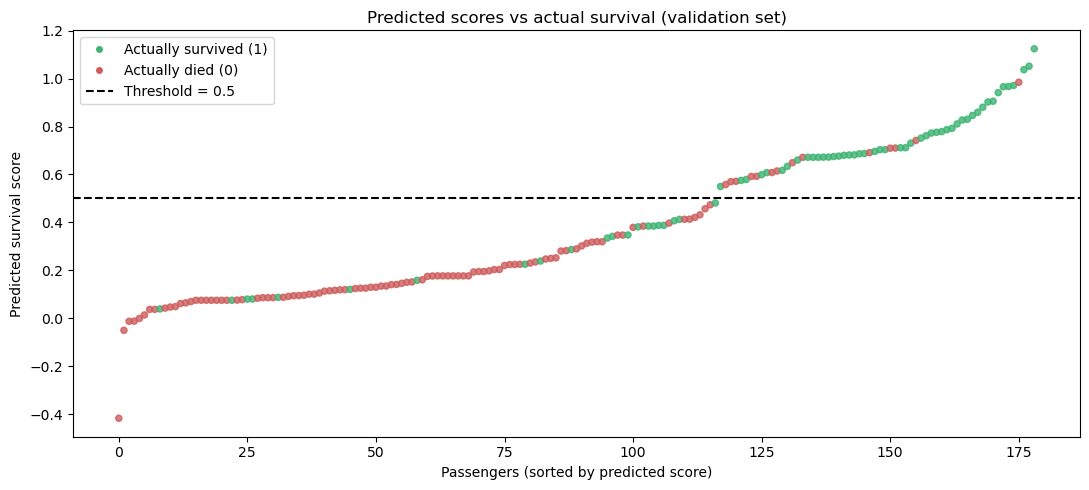

In [19]:
# Scatter: predicted score vs actual class, with the decision threshold line.
# Passengers are sorted by score (x-axis is just rank, for readability).
order = np.argsort(val_scores)
scores_sorted = val_scores[order]
y_sorted = y_val.values[order]

plt.figure(figsize=(11, 5))
colors = np.where(y_sorted == 1, "mediumseagreen", "indianred")
plt.scatter(range(len(scores_sorted)), scores_sorted, c=colors, s=20, alpha=0.8)

# The decision threshold: points ABOVE the line -> predicted survived
plt.axhline(THRESHOLD, color="black", linestyle="--", linewidth=1.5)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="mediumseagreen", label="Actually survived (1)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="indianred", label="Actually died (0)"),
    Line2D([0], [0], color="black", linestyle="--", label=f"Threshold = {THRESHOLD}"),
]
plt.legend(handles=legend)
plt.xlabel("Passengers (sorted by predicted score)")
plt.ylabel("Predicted survival score")
plt.title("Predicted scores vs actual survival (validation set)")
plt.tight_layout()
plt.show()